# Ejercicio de repaso — ThinkDSP

Resolución paso a paso siguiendo la plantilla de la evaluación.

In [1]:
import thinkdsp
import matplotlib.pyplot as plt

---
## Ejercicio 1

`diente_sierra.wav` fue muestreada a 9000 Hz. Se pide determinar su fundamental y aislarla de las componentes con aliasing.

### Tu turno — Paso 1: cargar y escuchar la señal

In [2]:
wave = thinkdsp.read_wave('diente_sierra.wav')
wave.normalize()
wave.make_audio()

### Tu turno — Paso 2: observar el espectro completo

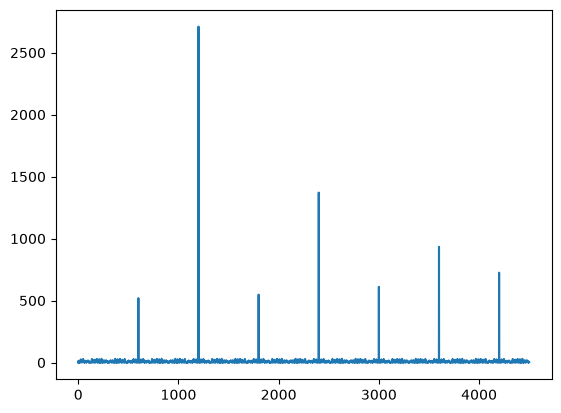

In [3]:
spectrum = wave.make_spectrum()
spectrum.plot()

### Tu turno — Paso 3: calcular la frecuencia de Nyquist

In [4]:
nyquist = wave.framerate / 2
print('Frecuencia de Nyquist:', nyquist, 'Hz')

Frecuencia de Nyquist: 4500.0 Hz


### Tu turno — Paso 4: identificar la fundamental y comparar con una señal sintética

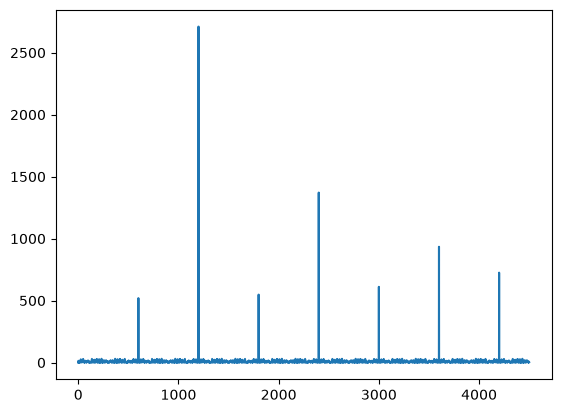

In [5]:
thinkdsp.SawtoothSignal(1200).make_wave(framerate=wave.framerate).make_spectrum().plot()

### Tu turno — Paso 5: filtrar para eliminar el aliasing

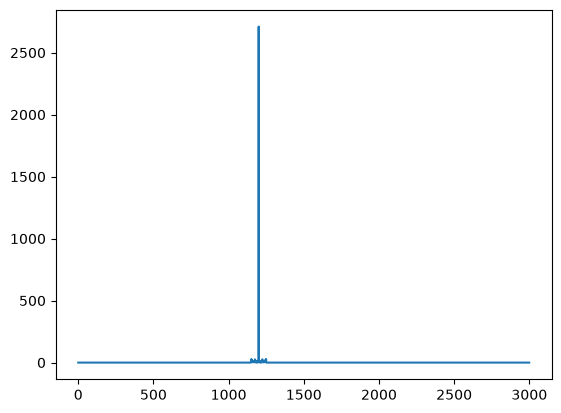

In [6]:
spectrum.high_pass(1150)
spectrum.low_pass(1250)
spectrum.plot(high=3000)
spectrum.make_wave().make_audio()

**Conclusión:** la fundamental es **1200 Hz**. Nyquist es 4500 Hz. El diente de sierra tiene todos los armónicos; los superiores a 4500 Hz se pliegan y generan aliasing. El filtro entre 1150 y 1250 Hz conserva sólo la fundamental.

---
## Ejercicio 2

`desconocida2.wav` dura tres segundos. Se analiza por tramos con un espectrograma.

### Tu turno — Paso 1: cargar y escuchar

In [7]:
wave2 = thinkdsp.read_wave('desconocida2.wav')
wave2.normalize()
wave2.make_audio()

### Tu turno — Paso 2: espectrogramas con distintos largos de segmento

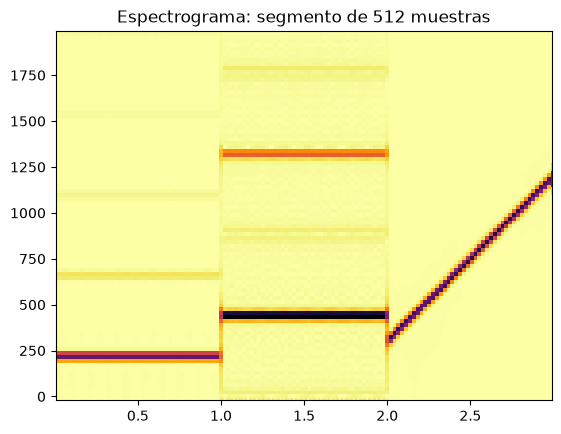

In [8]:
for largo in [256, 512]:
    spectrogram = wave2.make_spectrogram(largo)
    spectrogram.plot(high=2000)
    plt.title(f'Espectrograma: segmento de {largo} muestras')

### Tu turno — Paso 3: análisis por tramos

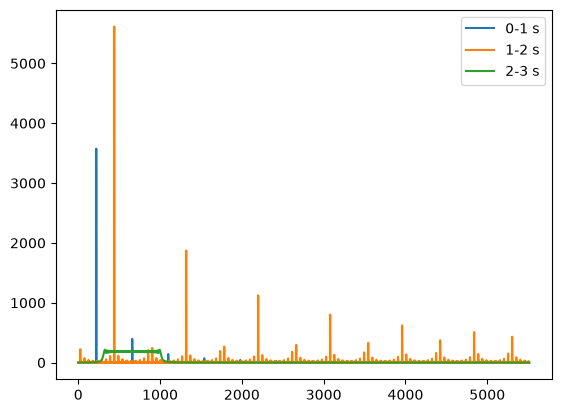

In [9]:
for inicio in [0, 1, 2]:
    segment = wave2.segment(start=inicio, duration=0.8)
    segment.make_spectrum().plot(label=f'{inicio}-{inicio + 1} s')
plt.legend()

**Conclusión:**

- Tramo 0–1 s: **onda triangular de 220 Hz**; se ven armónicos impares que decrecen rápidamente.
- Tramo 1–2 s: **onda cuadrada de 440 Hz**; tiene niveles discretos y armónicos impares.
- Tramo 2–3 s: **chirp lineal cosenoidal**, cuya frecuencia aumenta aproximadamente de 300 a 1200 Hz.

Las líneas horizontales del espectrograma representan frecuencias constantes; la línea inclinada del último tramo muestra una frecuencia que cambia con el tiempo.

---
## Ejercicio 3

Las opciones son: triangular de 1000 Hz, triangular de 1800 Hz, diente de sierra de 1400 Hz o cosenoidal de 600 Hz.

### Tu turno — Paso 1: cargar y escuchar

In [10]:
wave3 = thinkdsp.read_wave('incognita2.wav')
wave3.normalize()
wave3.make_audio()

### Tu turno — Paso 2: mirar la forma de onda en el tiempo

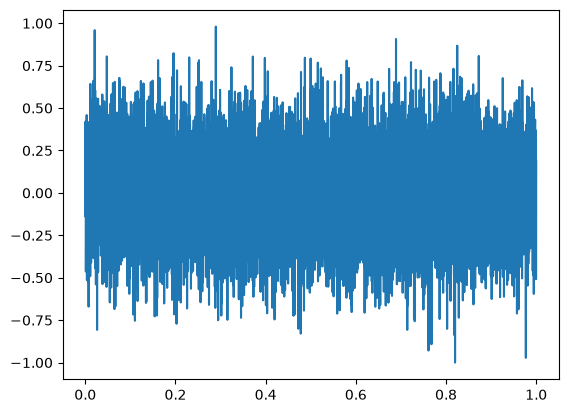

In [11]:
wave3.plot()

### Tu turno — Paso 3: analizar el espectro

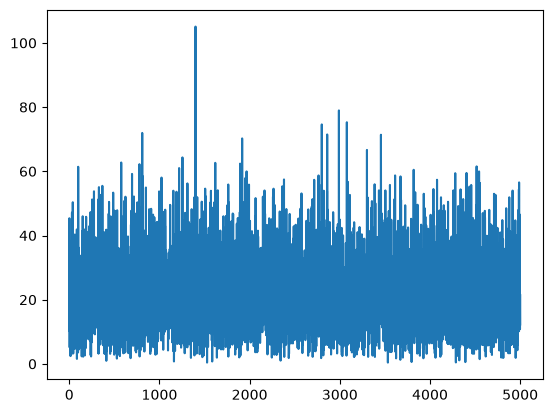

In [12]:
spectrum3 = wave3.make_spectrum()
spectrum3.plot()

### Tu turno — Paso 4: razonar sobre las 4 hipótesis

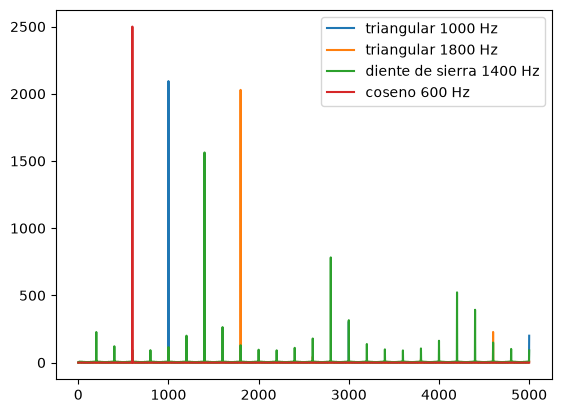

In [13]:
candidatos = {
    'triangular 1000 Hz': thinkdsp.TriangleSignal(1000),
    'triangular 1800 Hz': thinkdsp.TriangleSignal(1800),
    'diente de sierra 1400 Hz': thinkdsp.SawtoothSignal(1400),
    'coseno 600 Hz': thinkdsp.CosSignal(600),
}

for nombre, senal in candidatos.items():
    senal.make_wave(duration=0.5, framerate=wave3.framerate).make_spectrum().plot(label=nombre)
plt.legend()

**Conclusión:** sí hay una señal enmascarada. Es una **onda diente de sierra de 1400 Hz**, porque el espectro tiene una fundamental cercana a 1400 Hz y varios armónicos pares e impares sobre el ruido. Esto descarta una cosenoide (un solo pico) y las triangulares (sólo armónicos impares).